## Build a Simple Neural Network from Scratch in PyTorch

In this notebook, we build and train a minimal linear neural network to learn a synthetic target function.

### Learning goals
- Understand how to define a model with `nn.Module`
- Create synthetic training data
- Train with gradient descent (`Adam` + `MSELoss`)
- Visualize predictions vs. ground truth
- Inspect learned parameters

In [53]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility: keep random values consistent across runs.
_ = torch.manual_seed(42)

### 1) Define the model

We start with a single linear layer implemented manually using learnable parameters:

$$\hat{y} = XW + b$$

This keeps the math transparent and makes backpropagation behavior easy to observe.

In [48]:
class SimpleNN(nn.Module):
    """A minimal linear model: y = XW + b."""

    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.matrix = nn.Parameter(torch.randn(in_dim, out_dim))
        self.bias = nn.Parameter(torch.randn(out_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x @ self.matrix + self.bias

### 2) Create a synthetic regression dataset

We generate data from a known linear rule:

$$y = XW_{true} + b_{true}$$

Because we know the true parameters, we can later compare them with the learned parameters.

In [49]:
def target_function(x: torch.Tensor, true_matrix: torch.Tensor, true_bias: torch.Tensor) -> torch.Tensor:
    """Generate targets from a known linear mapping."""
    return x @ true_matrix + true_bias

### 3) Train the model

We train with Mean Squared Error (MSE) and Adam optimizer. The loss should decrease as the model parameters approach the true parameters.

In [50]:
# Training data
num_samples = 100
in_dim = 2
out_dim = 1

x = torch.randn(num_samples, in_dim)
true_matrix = torch.tensor([[2.0], [-3.0]])
true_bias = torch.tensor([1.0])
y = target_function(x, true_matrix, true_bias)

print(f"Input shape: {x.shape}, target shape: {y.shape}")

# Model, loss, optimizer
model = SimpleNN(in_dim=in_dim, out_dim=out_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
num_epochs = 500

# Training loop
for epoch in range(num_epochs):
    pred = model(x)
    loss = criterion(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.6f}")

Input shape: torch.Size([100, 2]), target shape: torch.Size([100, 1])
Epoch   0 | Loss: 14.222265
Epoch 100 | Loss: 0.014955
Epoch 200 | Loss: 0.000000
Epoch 300 | Loss: 0.000000
Epoch 400 | Loss: 0.000000


### 4) Visualize predictions vs. targets

If training is successful, red points (predictions) should overlap blue points (ground truth).

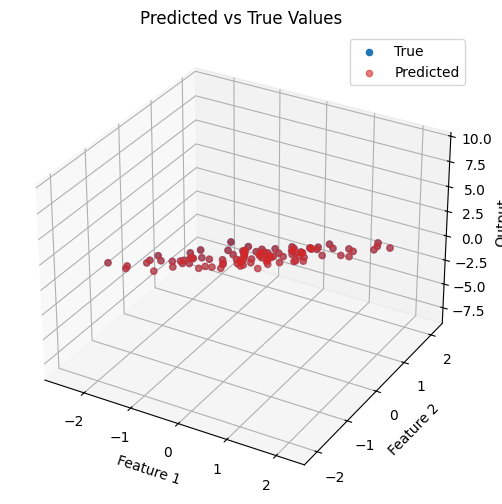

In [51]:
with torch.no_grad():
    pred = model(x)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x[:, 0].numpy(), x[:, 1].numpy(), y[:, 0].numpy(), label="True", color="tab:blue")
ax.scatter(
    x[:, 0].numpy(),
    x[:, 1].numpy(),
    pred[:, 0].numpy(),
    label="Predicted",
    color="tab:red",
    alpha=0.6,
)

ax.legend()
ax.set_title("Predicted vs True Values")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Output")
plt.show()

### 5) Compare learned parameters with true parameters

A well-trained linear model should recover values close to $W_{true}$ and $b_{true}$.

In [52]:
print("True matrix:\n", true_matrix)
print("Learned matrix:\n", model.matrix.data)
print()
print("True bias:", true_bias)
print("Learned bias:", model.bias.data)

True matrix:
 tensor([[ 2.],
        [-3.]])
Learned matrix:
 tensor([[ 2.0000],
        [-3.0000]])

True bias: tensor([1.])
Learned bias: tensor([1.0000])
